<a href="https://colab.research.google.com/github/cephav/Celebal_Assignment1/blob/main/week2_CephaAbhishek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import kagglehub
import pandas as pd
import os

# Download latest version (re-including this to ensure 'path' is defined)
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")
print("Path to dataset files:", path)

# Construct the full path to the extracted dataset directory
# The 'path' variable already points to the root of the extracted dataset.
# No need to append the dataset name again.
dataset_dir = path # Corrected line

# List all files in the directory to identify the CSV files
csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]
print(f"Found CSV files: {csv_files}")

# Let's try to load the 'Tesla EA Deliveries and Production Data 2015-2025.csv' first if it exists.
# If not, we'll load the first found CSV.
main_csv_file = None
if 'Tesla EA Deliveries and Production Data 2015-2025.csv' in csv_files:
    main_csv_file = 'Tesla EA Deliveries and Production Data 2015-2025.csv'
elif csv_files:
    main_csv_file = csv_files[0] # Fallback to the first found CSV

if main_csv_file:
    df_path = os.path.join(dataset_dir, main_csv_file)
    df = pd.read_csv(df_path)
    print(f"Loaded '{main_csv_file}' into a DataFrame.")
    print("First 5 rows of the dataset:")
    display(df.head())
else:
    print("No CSV files found in the dataset directory.")

Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Path to dataset files: /kaggle/input/tesla-ea-deliveries-and-production-data20152025
Found CSV files: ['tesla_deliveries_dataset_2015_2025.csv']
Loaded 'tesla_deliveries_dataset_2015_2025.csv' into a DataFrame.
First 5 rows of the dataset:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [20]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\nDescriptive Statistics:")
display(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

Missing values per column:
Series([], dtype: int64)

Descriptive Statistics:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [21]:
# Combine 'Year' and 'Month' to create a 'Date' column
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Set 'Date' as the DataFrame index and sort it
df = df.set_index('Date').sort_index()

# Drop 'Year' and 'Month' columns as they are now redundant
df = df.drop(columns=['Year', 'Month'])

print("DataFrame after creating datetime index:")
df.info()
print("\nFirst 5 rows with new datetime index:")
display(df.head())

DataFrame after creating datetime index:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2640 entries, 2015-01-01 to 2025-12-01
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Region                2640 non-null   object 
 1   Model                 2640 non-null   object 
 2   Estimated_Deliveries  2640 non-null   int64  
 3   Production_Units      2640 non-null   int64  
 4   Avg_Price_USD         2640 non-null   float64
 5   Battery_Capacity_kWh  2640 non-null   int64  
 6   Range_km              2640 non-null   int64  
 7   CO2_Saved_tons        2640 non-null   float64
 8   Source_Type           2640 non-null   object 
 9   Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 226.9+ KB

First 5 rows with new datetime index:


,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
Date,,,,,,,,,,
2015-01-01,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390
2015-01-01,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925
2015-01-01,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923
2015-01-01,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170
2015-01-01,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626


Computing and visualizing the correlation matrix...


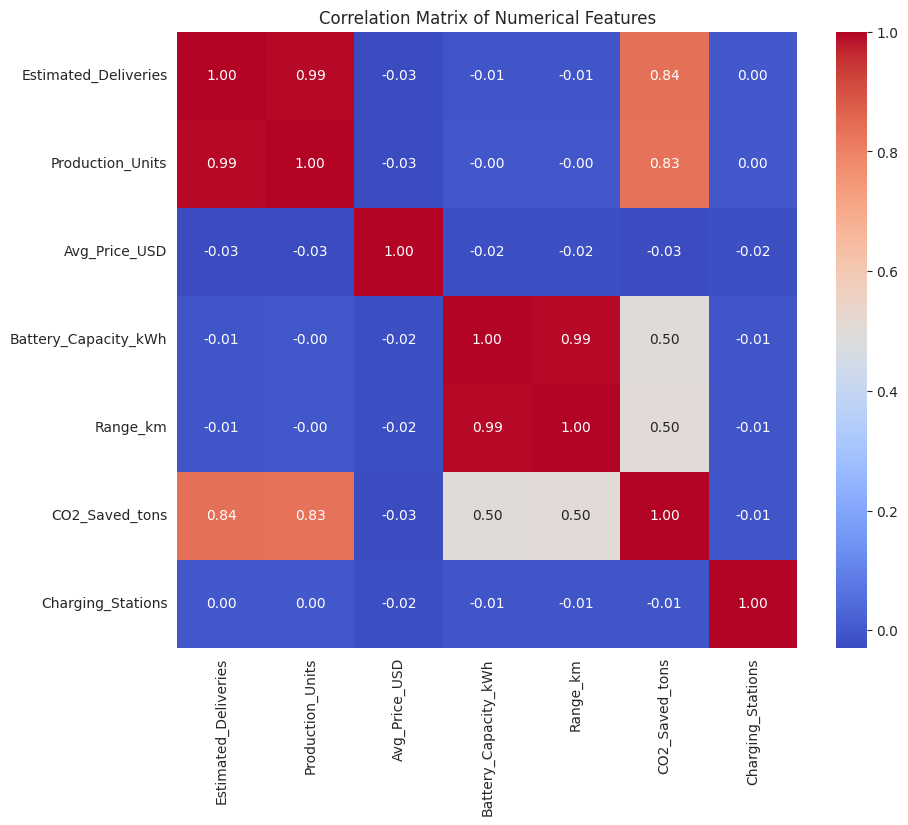

Correlation matrix computed and displayed. This shows the linear relationships between the numerical features.


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Computing and visualizing the correlation matrix...")

# Select only numerical columns for correlation matrix
# Exclude one-hot encoded columns from this particular correlation matrix for clarity if they are too many,
# focusing on original numerical features and the target.

numerical_df = df_encoded[['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                          'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']]

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("Correlation matrix computed and displayed. This shows the linear relationships between the numerical features.")

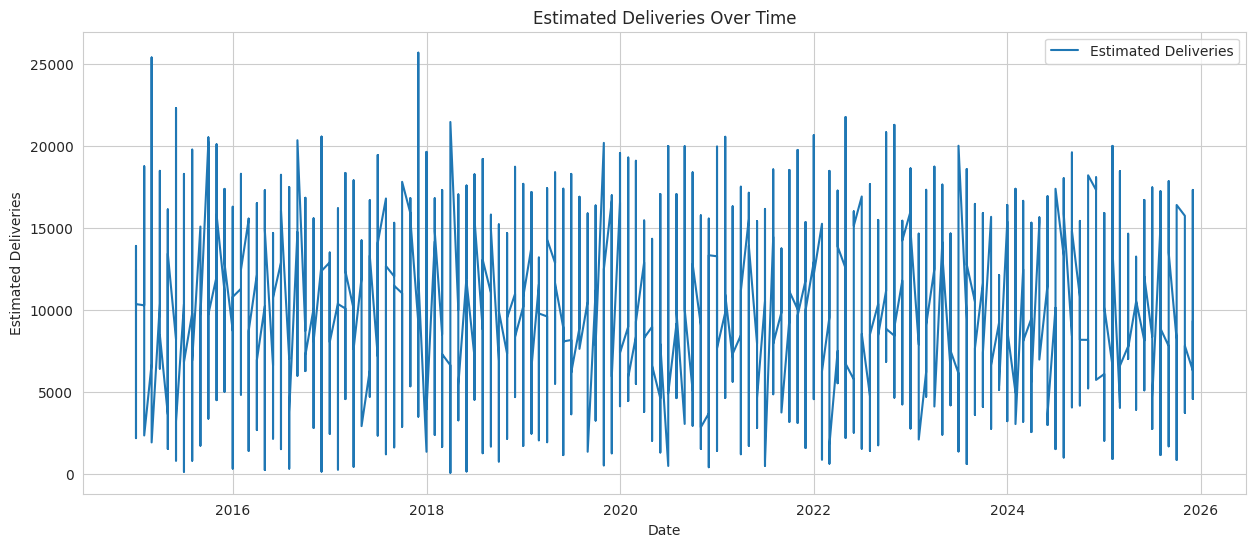

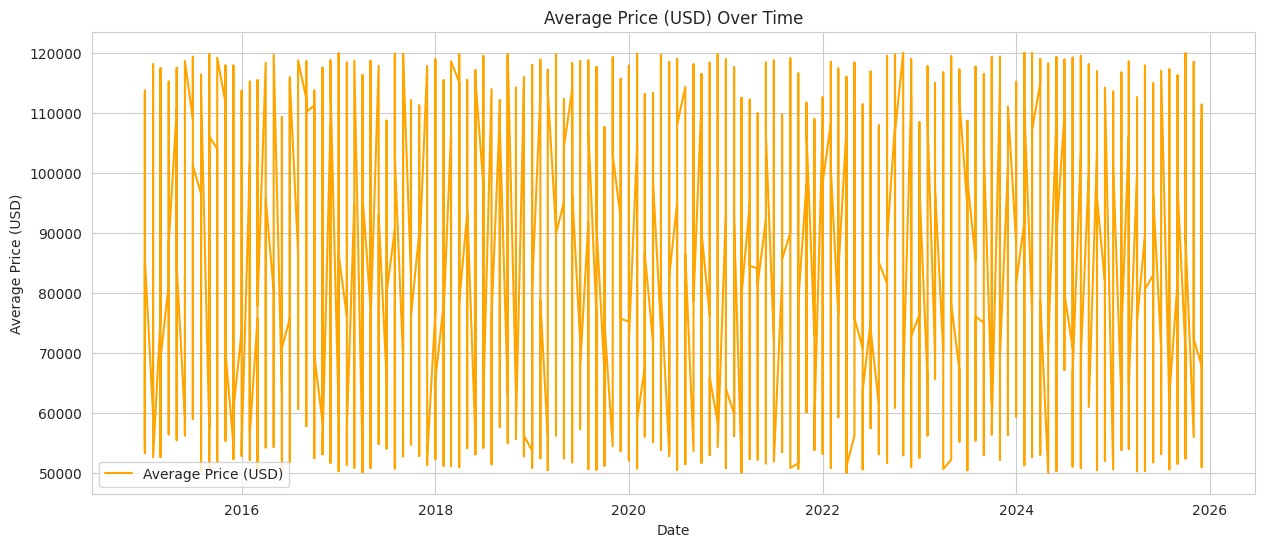

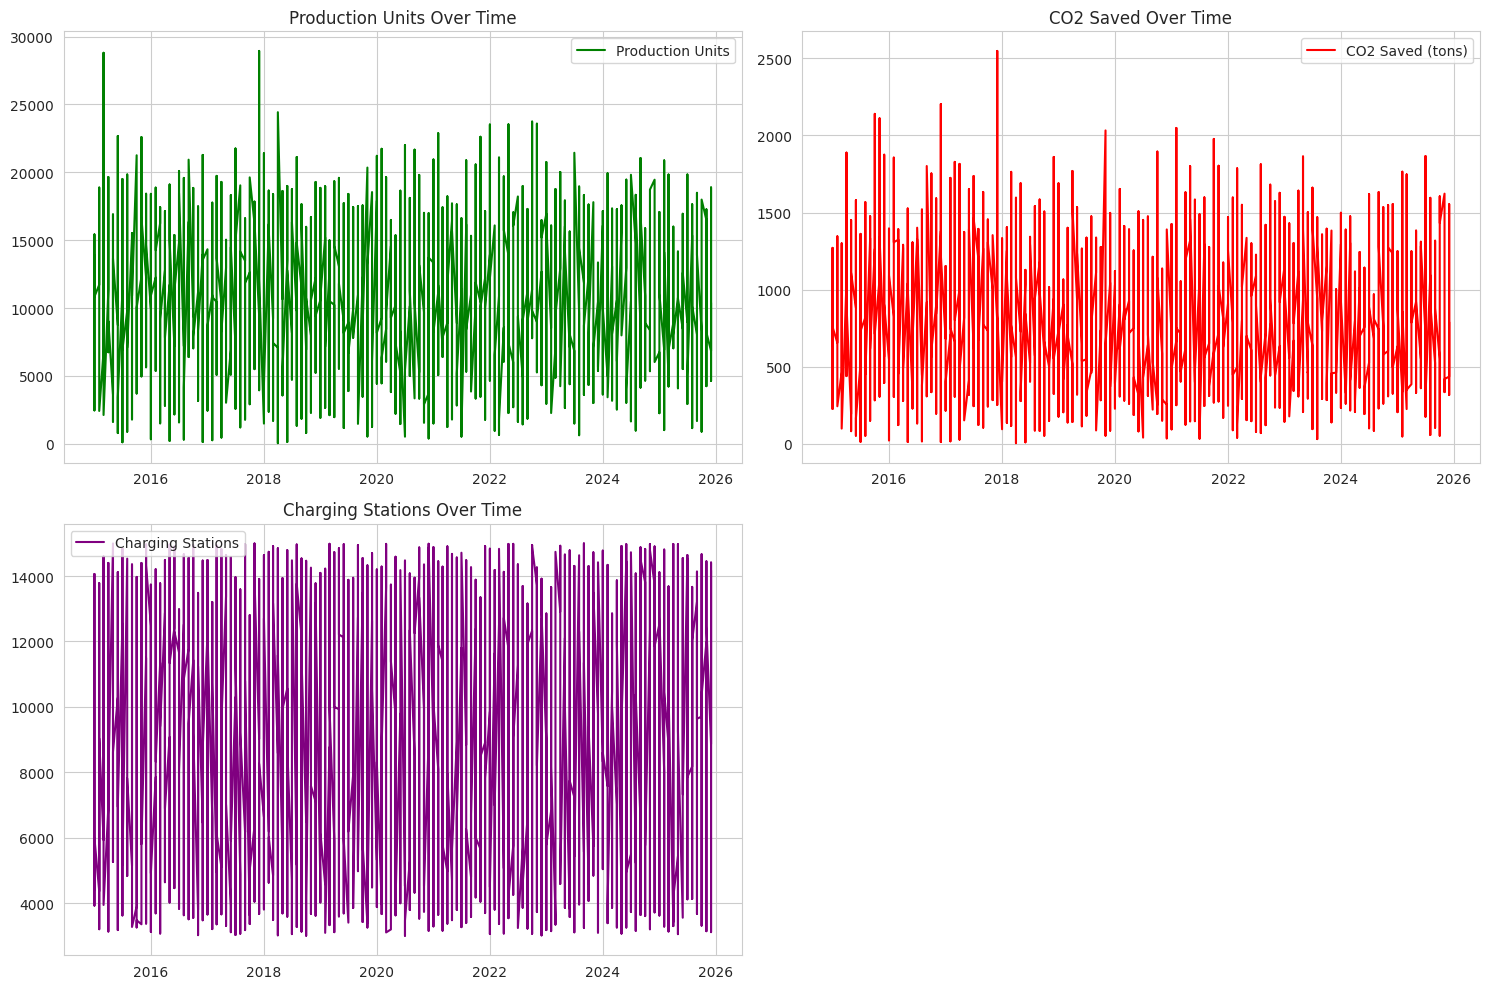

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Estimated_Deliveries'], label='Estimated Deliveries')
plt.title('Estimated Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Avg_Price_USD'], label='Average Price (USD)', color='orange')
plt.title('Average Price (USD) Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price (USD)')
plt.legend()
plt.show()

# Also visualize other potentially important numerical features
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.plot(df.index, df['Production_Units'], label='Production Units', color='green')
plt.title('Production Units Over Time')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(df.index, df['CO2_Saved_tons'], label='CO2 Saved (tons)', color='red')
plt.title('CO2 Saved Over Time')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(df.index, df['Charging_Stations'], label='Charging Stations', color='purple')
plt.title('Charging Stations Over Time')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Identify categorical columns
categorical_cols = ['Region', 'Model', 'Source_Type']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())
print(f"New shape of DataFrame: {df_encoded.shape}")

DataFrame after one-hot encoding:


,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
Date,,,,,,,,,,,,,,,,
2015-01-01,12446,13885,55183.13,60,340,634.75,4390,False,False,False,False,False,False,True,False,True
2015-01-01,11446,12752,89289.40,100,588,1009.54,8925,False,True,False,True,False,False,False,False,False
2015-01-01,8803,9344,102888.58,60,336,443.67,3923,False,True,False,False,False,False,False,True,False
2015-01-01,6367,6802,104962.32,82,459,438.37,9170,False,False,True,False,False,False,False,False,False
2015-01-01,8795,9165,87988.73,82,456,601.58,12626,False,False,False,True,False,False,False,False,True


New shape of DataFrame: (2640, 16)


In [25]:
from sklearn.model_selection import train_test_split

# Define target variable (y) and features (X)
y = df_encoded['Estimated_Deliveries']
X = df_encoded.drop(columns=['Estimated_Deliveries'])

# Split data into training and testing sets based on time
# Using the first 80% of data for training and the last 20% for testing
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2112, 15)
Shape of X_test: (528, 15)
Shape of y_train: (2112,)
Shape of y_test: (528,)


Linear Regression Model Performance:
Mean Squared Error: 152207.98
R-squared: 0.99


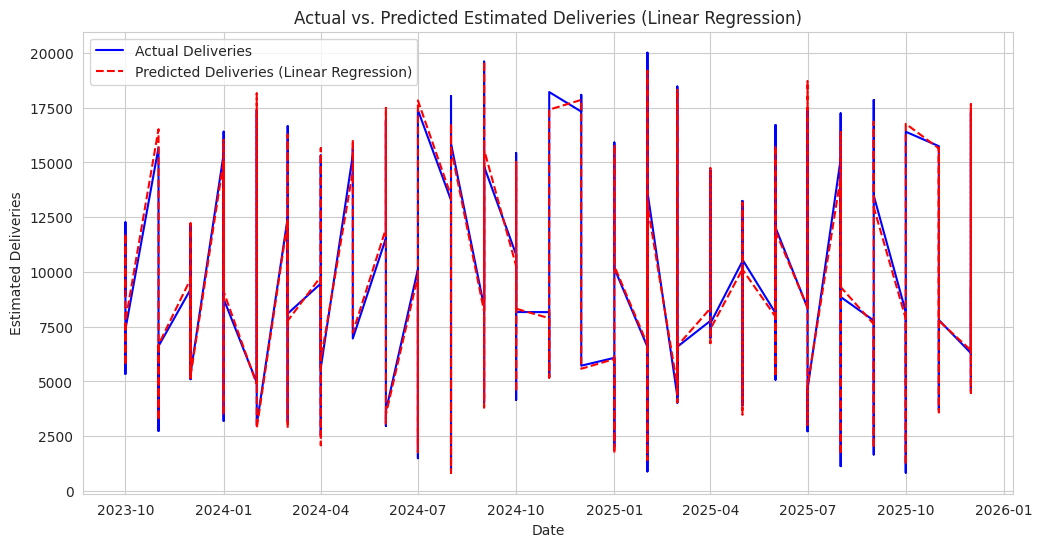

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Performance:")
print(f"Mean Squared Error: {mse_lr:.2f}")
print(f"R-squared: {r2_lr:.2f}")

# Plot actual vs. predicted values for Linear Regression
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Deliveries', color='blue')
plt.plot(y_test.index, y_pred_lr, label='Predicted Deliveries (Linear Regression)', color='red', linestyle='--')
plt.title('Actual vs. Predicted Estimated Deliveries (Linear Regression)')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.show()

Ridge Regression Model Performance:
Mean Squared Error: 152202.73
R-squared: 0.99


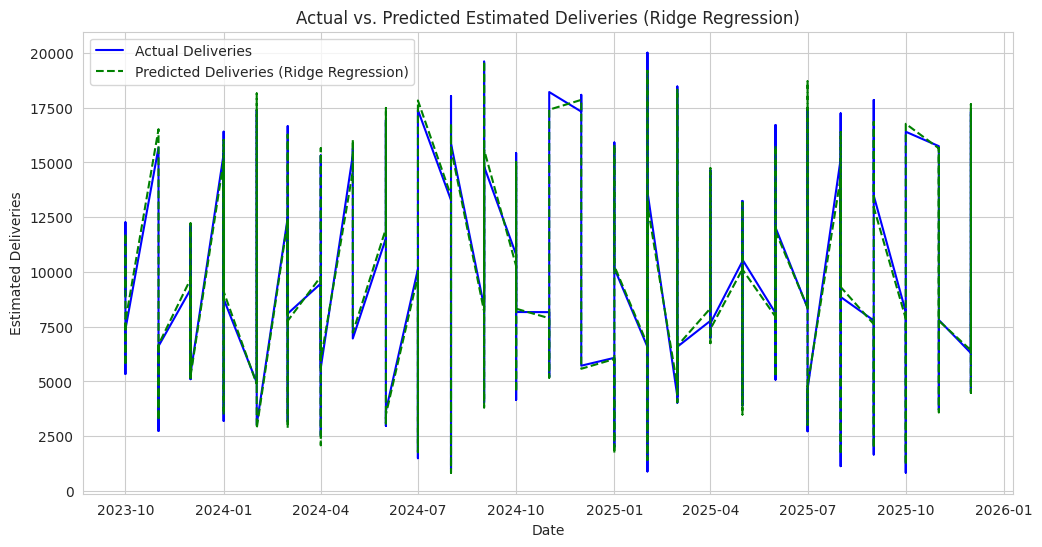

In [27]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge Regression model
# You can experiment with different alpha values
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate the model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Model Performance:")
print(f"Mean Squared Error: {mse_ridge:.2f}")
print(f"R-squared: {r2_ridge:.2f}")

# Plot actual vs. predicted values for Ridge Regression
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Deliveries', color='blue')
plt.plot(y_test.index, y_pred_ridge, label='Predicted Deliveries (Ridge Regression)', color='green', linestyle='--')
plt.title('Actual vs. Predicted Estimated Deliveries (Ridge Regression)')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.show()

Lasso Regression Model Performance:
Mean Squared Error: 152178.65
R-squared: 0.99


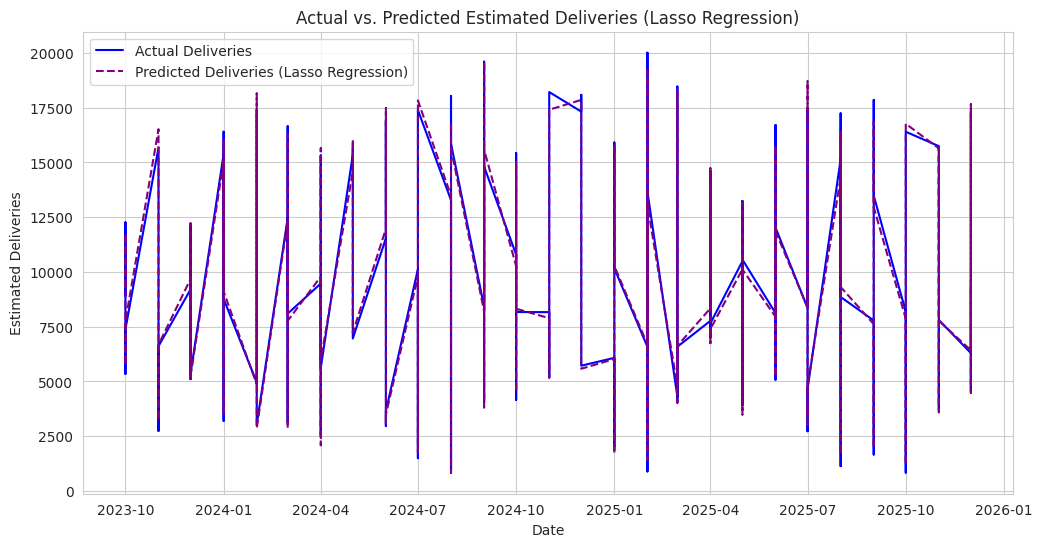

In [28]:
from sklearn.linear_model import Lasso

# Initialize and train the Lasso Regression model
# You can experiment with different alpha values. A small alpha might be a good starting point.
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the model
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Model Performance:")
print(f"Mean Squared Error: {mse_lasso:.2f}")
print(f"R-squared: {r2_lasso:.2f}")

# Plot actual vs. predicted values for Lasso Regression
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Deliveries', color='blue')
plt.plot(y_test.index, y_pred_lasso, label='Predicted Deliveries (Lasso Regression)', color='purple', linestyle='--')
plt.title('Actual vs. Predicted Estimated Deliveries (Lasso Regression)')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.show()

Implementing ARIMA Model...
                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  105
Model:                   ARIMA(5, 1, 0)   Log Likelihood               -1186.792
Date:                  Mon, 08 Jun 2026   AIC                           2385.585
Time:                          13:25:39   BIC                           2401.451
Sample:                      01-01-2015   HQIC                          2392.013
                           - 09-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4834      0.053     -9.161      0.000      -0.587      -0.380
ar.L2         -0.2716      0.057     -4.741      0.000      -0.384      -0.159
ar.L3   

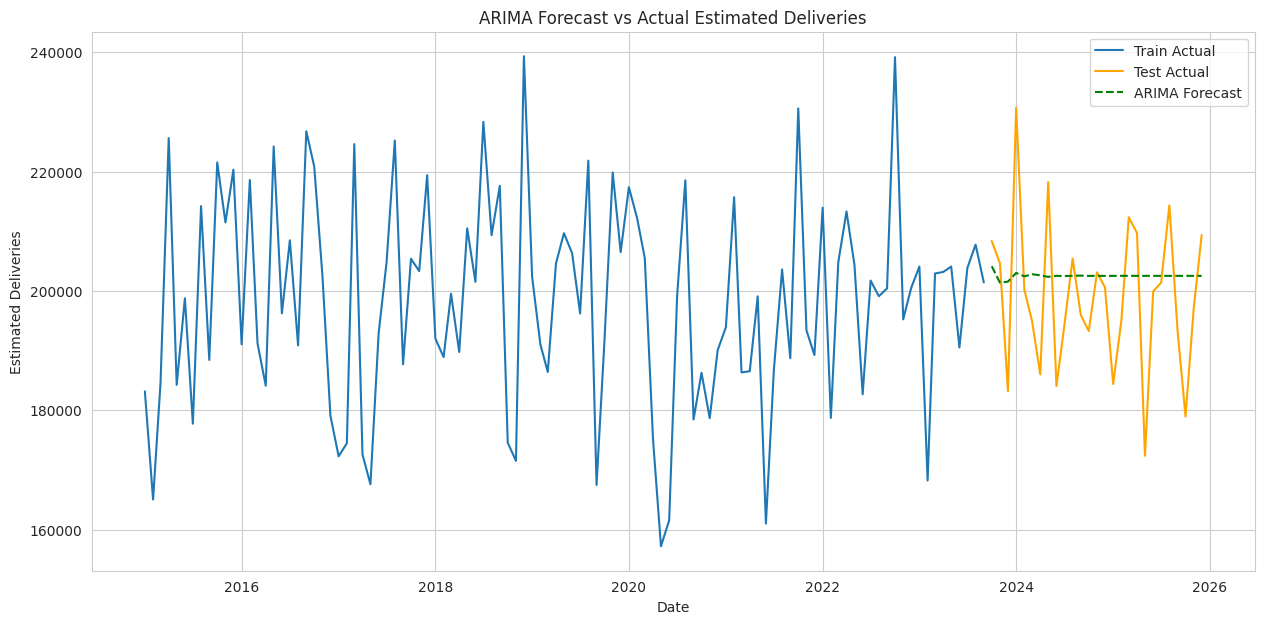

In [29]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore') # Suppress warnings from ARIMA

print("Implementing ARIMA Model...")

# For ARIMA, we typically use a single time series. Let's use the 'Estimated_Deliveries' from the original df
# For simplicity, we'll use the aggregated monthly deliveries for time series forecasting.
# First, ensure the original df is sorted by Date and aggregate deliveries if multiple entries per month exist.

df_ts = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
df_ts = df_ts.set_index('Date').sort_index()

# Split time series data (e.g., 80% train, 20% test)
train_size_ts = int(len(df_ts) * 0.8)
train_ts, test_ts = df_ts.iloc[:train_size_ts], df_ts.iloc[train_size_ts:]

# Fit ARIMA model
# (p,d,q) parameters need to be carefully chosen. For demonstration, we'll use a common set.
# A more robust approach would involve ACF/PACF plots or auto_arima.
order = (5,1,0) # Example order: AR(5), differencing(1), MA(0)

# Try to fit the ARIMA model, catching potential errors
try:
    arima_model = ARIMA(train_ts, order=order)
    arima_results = arima_model.fit()
    print(arima_results.summary())

    # Make predictions
    start_index = len(train_ts)
    end_index = len(df_ts) - 1
    forecast_arima = arima_results.predict(start=start_index, end=end_index, typ='levels')
    forecast_arima.index = test_ts.index

    # Evaluate ARIMA
    mse_arima = mean_squared_error(test_ts, forecast_arima)
    r2_arima = r2_score(test_ts, forecast_arima)
    print(f"\nARIMA Model Performance (Order {order}):")
    print(f"Mean Squared Error: {mse_arima:.2f}")
    print(f"R-squared: {r2_arima:.2f}")

    # Plot ARIMA forecast
    plt.figure(figsize=(15, 7))
    plt.plot(train_ts.index, train_ts, label='Train Actual')
    plt.plot(test_ts.index, test_ts, label='Test Actual', color='orange')
    plt.plot(forecast_arima.index, forecast_arima, label='ARIMA Forecast', color='green', linestyle='--')
    plt.title('ARIMA Forecast vs Actual Estimated Deliveries')
    plt.xlabel('Date')
    plt.ylabel('Estimated Deliveries')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"Error fitting ARIMA model: {e}")
    print("You might need to adjust the ARIMA order (p,d,q) or preprocess the time series further.")

Implementing VAR Model...
ADF Test for Estimated_Deliveries:
  ADF Statistic: -8.88
  p-value: 0.00
  Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
  --> Estimated_Deliveries is Stationary (p-value <= 0.05)

ADF Test for Production_Units:
  ADF Statistic: -8.97
  p-value: 0.00
  Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
  --> Production_Units is Stationary (p-value <= 0.05)

ADF Test for Avg_Price_USD:
  ADF Statistic: -9.89
  p-value: 0.00
  Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
  --> Avg_Price_USD is Stationary (p-value <= 0.05)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 08, Jun, 2026
Time:                     13:25:39
--------

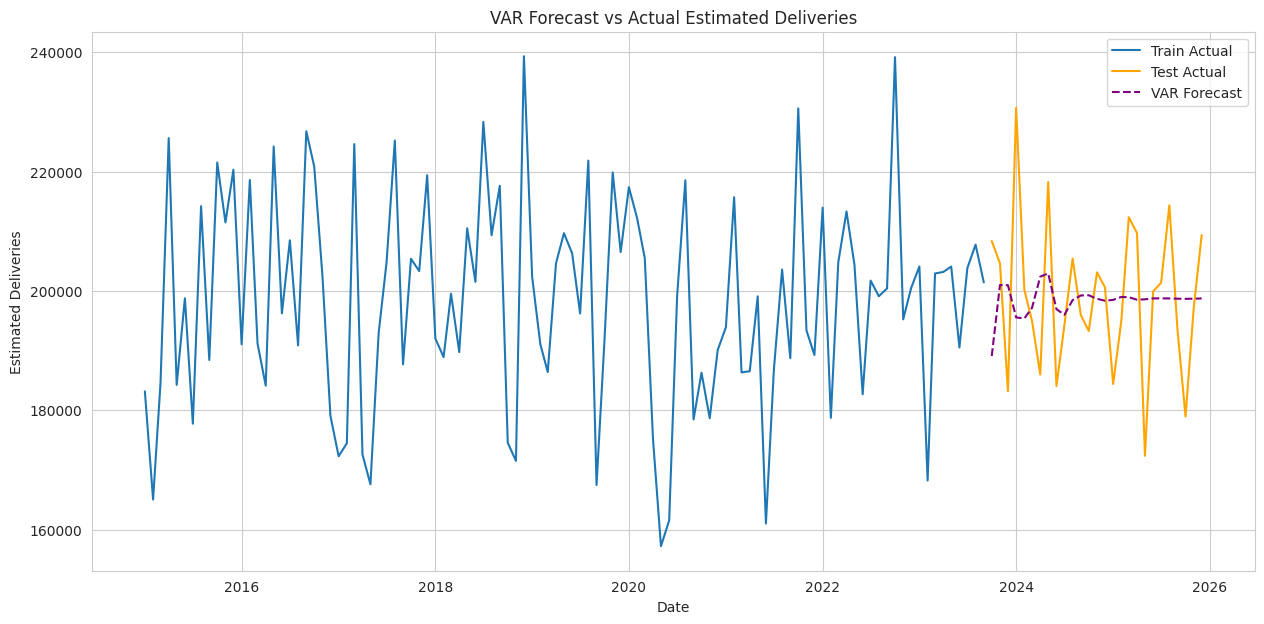

In [30]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

print("Implementing VAR Model...")

# For VAR, we need multiple time series. Let's select relevant numerical columns from df_ts.
# It's important that the series are stationary for VAR.

# Let's consider 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD'
# First, we need to ensure these are aggregated by month if there are multiple entries per month.
# The df was already indexed by Date and Year/Month were dropped.
# We need to re-create a monthly aggregated dataframe with these features.

df_var = df.groupby('Date')[['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']].sum()

# Check for stationarity using Augmented Dickey-Fuller test
def adf_test(series, name=''):
    result = adfuller(series, autolag='AIC')
    print(f'ADF Test for {name}:')
    print(f'  ADF Statistic: {result[0]:.2f}')
    print(f'  p-value: {result[1]:.2f}')
    print(f'  Critical Values: {result[4]}')
    if result[1] <= 0.05:
        print(f'  --> {name} is Stationary (p-value <= 0.05)\n')
    else:
        print(f'  --> {name} is Non-Stationary (p-value > 0.05)\n')
        return False
    return True

# Apply differencing if non-stationary
is_stationary = True
for col in df_var.columns:
    if not adf_test(df_var[col], col):
        is_stationary = False

if not is_stationary:
    print("At least one series is non-stationary. Applying first-order differencing.")
    df_var_diff = df_var.diff().dropna()
    for col in df_var_diff.columns:
        adf_test(df_var_diff[col], f'{col} (Differenced)')
    data_for_var = df_var_diff
else:
    data_for_var = df_var

# Split VAR data
train_size_var = int(len(data_for_var) * 0.8)
train_var, test_var = data_for_var.iloc[:train_size_var], data_for_var.iloc[train_size_var:]

# Fit VAR model
# Choose lag order (e.g., 5). This also needs careful selection (e.g., using information criteria).
lag_order = 5
try:
    var_model = VAR(train_var)
    var_results = var_model.fit(lag_order)
    print(var_results.summary())

    # Make predictions
    # Get the last 'lag_order' observations from the training data for forecasting
    last_train_values = train_var.values[-lag_order:]
    forecast_var = var_results.forecast(y=last_train_values, steps=len(test_var))

    # Re-index the forecast to the test set dates
    forecast_df_var = pd.DataFrame(forecast_var, index=test_var.index, columns=test_var.columns)

    # If differencing was applied, invert the differencing to get original scale predictions
    if not is_stationary:
        # To invert differencing, we need the last actual value before differencing for each series
        last_original_train_values = df_var.iloc[train_size_var - 1][test_var.columns]
        forecast_original_scale = last_original_train_values + forecast_df_var.cumsum()
    else:
        forecast_original_scale = forecast_df_var

    # Evaluate VAR for 'Estimated_Deliveries'
    mse_var = mean_squared_error(test_var['Estimated_Deliveries'], forecast_df_var['Estimated_Deliveries'])
    r2_var = r2_score(test_var['Estimated_Deliveries'], forecast_df_var['Estimated_Deliveries'])

    print(f"\nVAR Model Performance for Estimated_Deliveries (Lag Order {lag_order}):")
    print(f"Mean Squared Error: {mse_var:.2f}")
    print(f"R-squared: {r2_var:.2f}")

    # Plot VAR forecast for Estimated_Deliveries
    plt.figure(figsize=(15, 7))
    plt.plot(train_var.index, train_var['Estimated_Deliveries'], label='Train Actual')
    plt.plot(test_var.index, test_var['Estimated_Deliveries'], label='Test Actual', color='orange')
    plt.plot(forecast_df_var.index, forecast_df_var['Estimated_Deliveries'], label='VAR Forecast', color='purple', linestyle='--')
    plt.title('VAR Forecast vs Actual Estimated Deliveries')
    plt.xlabel('Date')
    plt.ylabel('Estimated Deliveries')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"Error fitting VAR model: {e}")
    print("You might need to adjust the VAR lag order or ensure your series are stationary.")

Beginning Hyperparameter Tuning for ARIMA Model...
Best ARIMA Order: (1, 0, 1) with AIC: 2358.05

Tuned ARIMA Model Performance (Order (1, 0, 1)):
Mean Squared Error: 159178998.37
R-squared: -0.00


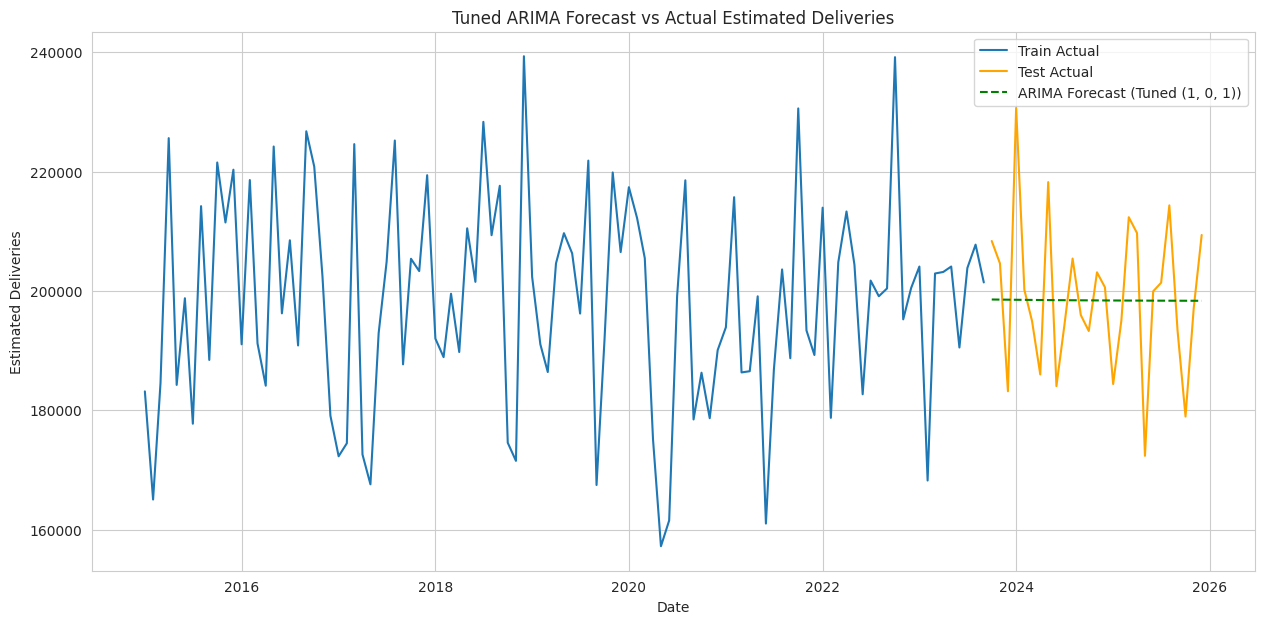

In [31]:
import itertools

print("Beginning Hyperparameter Tuning for ARIMA Model...")

# Define the p, d, q parameters to take any value between 0 and 3
p = d = q = range(0, 3)
# Generate all different combinations of p, q and q triplets
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_order = None
best_arima_model = None

# Iterate over all parameter combinations
for param in pdq:
    try:
        # Fit ARIMA model with current parameters
        model_arima = ARIMA(train_ts, order=param)
        results_arima = model_arima.fit()

        # Check if current model's AIC is better than the best found so far
        if results_arima.aic < best_aic:
            best_aic = results_arima.aic
            best_order = param
            best_arima_model = results_arima
    except Exception as e:
        # Skip models that fail to converge
        continue

print(f"Best ARIMA Order: {best_order} with AIC: {best_aic:.2f}")

# Re-fit with the best parameters and evaluate
if best_arima_model:
    # Make predictions with the best model
    start_index_best = len(train_ts)
    end_index_best = len(df_ts) - 1
    forecast_arima_tuned = best_arima_model.predict(start=start_index_best, end=end_index_best, typ='levels')
    forecast_arima_tuned.index = test_ts.index

    # Evaluate ARIMA tuned
    mse_arima_tuned = mean_squared_error(test_ts, forecast_arima_tuned)
    r2_arima_tuned = r2_score(test_ts, forecast_arima_tuned)
    print(f"\nTuned ARIMA Model Performance (Order {best_order}):")
    print(f"Mean Squared Error: {mse_arima_tuned:.2f}")
    print(f"R-squared: {r2_arima_tuned:.2f}")

    # Plot Tuned ARIMA forecast
    plt.figure(figsize=(15, 7))
    plt.plot(train_ts.index, train_ts, label='Train Actual')
    plt.plot(test_ts.index, test_ts, label='Test Actual', color='orange')
    plt.plot(forecast_arima_tuned.index, forecast_arima_tuned, label=f'ARIMA Forecast (Tuned {best_order})', color='green', linestyle='--')
    plt.title('Tuned ARIMA Forecast vs Actual Estimated Deliveries')
    plt.xlabel('Date')
    plt.ylabel('Estimated Deliveries')
    plt.legend()
    plt.show()
else:
    print("No stable ARIMA model found during tuning. Consider expanding parameter search space or data preprocessing.")

Beginning Hyperparameter Tuning for VAR Model...
Best VAR Lag Order: 1 with AIC: 57.54

Tuned VAR Model Performance for Estimated_Deliveries (Lag Order 1):
Mean Squared Error: 161781544.79
R-squared: -0.02


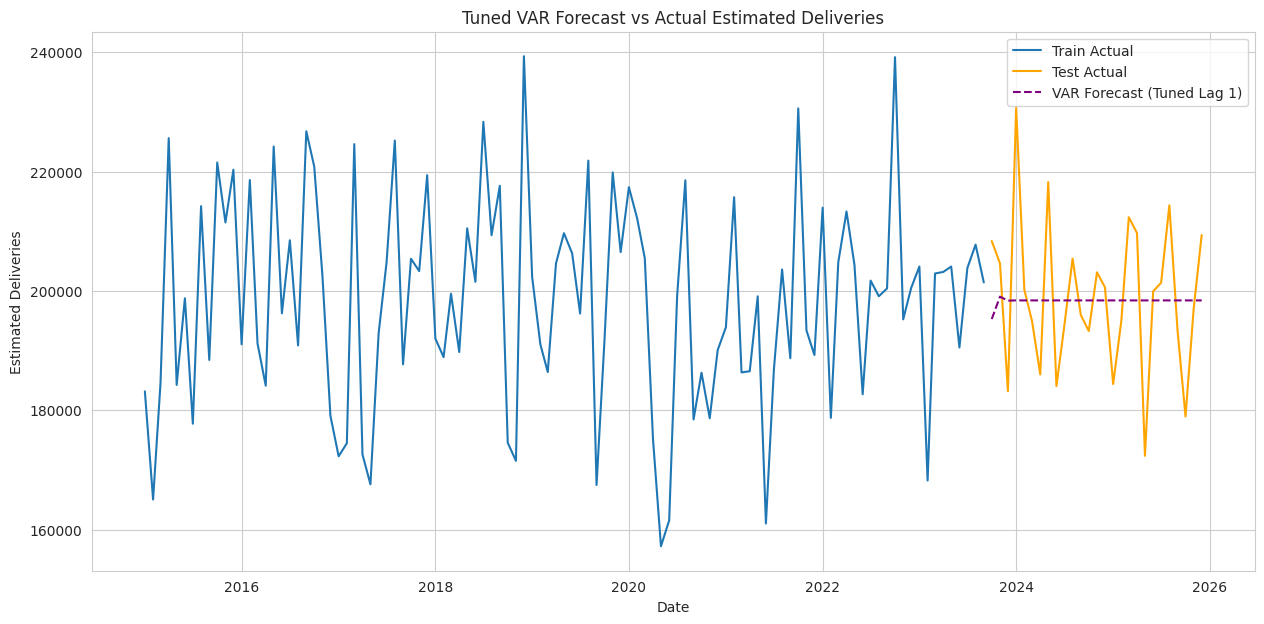

In [32]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.var_model import VARResults

print("Beginning Hyperparameter Tuning for VAR Model...")

# Define the maximum lag order to consider for VAR
max_lag_order = 10  # You can adjust this range

best_var_aic = float("inf")
best_var_lag_order = None
best_var_results = None

# Iterate over different lag orders
for lag in range(1, max_lag_order + 1):
    try:
        # Fit VAR model with current lag order
        model_var = VAR(train_var)
        results_var = model_var.fit(lag)

        # Check if current model's AIC is better than the best found so far
        # VARResults has an aic attribute
        if results_var.aic < best_var_aic:
            best_var_aic = results_var.aic
            best_var_lag_order = lag
            best_var_results = results_var
    except Exception as e:
        # Skip models that fail to converge or cause errors
        continue

print(f"Best VAR Lag Order: {best_var_lag_order} with AIC: {best_var_aic:.2f}")

# Re-fit with the best parameters and evaluate
if best_var_results:
    # Make predictions with the best model
    last_train_values_best = train_var.values[-best_var_lag_order:]
    forecast_var_tuned = best_var_results.forecast(y=last_train_values_best, steps=len(test_var))

    # Re-index the forecast to the test set dates
    forecast_df_var_tuned = pd.DataFrame(forecast_var_tuned, index=test_var.index, columns=test_var.columns)

    # If differencing was applied, invert the differencing to get original scale predictions
    # (assuming 'is_stationary' and 'df_var' are still available from previous cell)
    if not is_stationary:
        last_original_train_values_var = df_var.iloc[train_size_var - 1][test_var.columns]
        forecast_original_scale_var_tuned = last_original_train_values_var + forecast_df_var_tuned.cumsum()
    else:
        forecast_original_scale_var_tuned = forecast_df_var_tuned

    # Evaluate Tuned VAR for 'Estimated_Deliveries'
    mse_var_tuned = mean_squared_error(test_var['Estimated_Deliveries'], forecast_df_var_tuned['Estimated_Deliveries'])
    r2_var_tuned = r2_score(test_var['Estimated_Deliveries'], forecast_df_var_tuned['Estimated_Deliveries'])

    print(f"\nTuned VAR Model Performance for Estimated_Deliveries (Lag Order {best_var_lag_order}):")
    print(f"Mean Squared Error: {mse_var_tuned:.2f}")
    print(f"R-squared: {r2_var_tuned:.2f}")

    # Plot Tuned VAR forecast for Estimated_Deliveries
    plt.figure(figsize=(15, 7))
    plt.plot(train_var.index, train_var['Estimated_Deliveries'], label='Train Actual')
    plt.plot(test_var.index, test_var['Estimated_Deliveries'], label='Test Actual', color='orange')
    plt.plot(forecast_df_var_tuned.index, forecast_df_var_tuned['Estimated_Deliveries'], label=f'VAR Forecast (Tuned Lag {best_var_lag_order})', color='purple', linestyle='--')
    plt.title('Tuned VAR Forecast vs Actual Estimated Deliveries')
    plt.xlabel('Date')
    plt.ylabel('Estimated Deliveries')
    plt.legend()
    plt.show()
else:
    print("No stable VAR model found during tuning. Consider expanding parameter search space or data preprocessing.")

In [33]:
import joblib

print("Saving Models...")

# Define a directory to save the models
model_save_dir = "./tesla_models"
os.makedirs(model_save_dir, exist_ok=True)

# Save Linear Regression Model
joblib.dump(linear_model, os.path.join(model_save_dir, 'linear_regression_model.pkl'))
print("Linear Regression Model saved.")

# Save Ridge Regression Model
joblib.dump(ridge_model, os.path.join(model_save_dir, 'ridge_regression_model.pkl'))
print("Ridge Regression Model saved.")

# Save Lasso Regression Model
joblib.dump(lasso_model, os.path.join(model_save_dir, 'lasso_regression_model.pkl'))
print("Lasso Regression Model saved.")

# Save Tuned ARIMA Model (if found)
if best_arima_model:
    joblib.dump(best_arima_model, os.path.join(model_save_dir, 'arima_model_tuned.pkl'))
    print("Tuned ARIMA Model saved.")
else:
    print("Tuned ARIMA Model not available for saving.")

# Save Tuned VAR Model (if found)
if best_var_results:
    joblib.dump(best_var_results, os.path.join(model_save_dir, 'var_model_tuned.pkl'))
    print("Tuned VAR Model saved.")
else:
    print("Tuned VAR Model not available for saving.")

print(f"All models saved to: {model_save_dir}")

# Optionally, list the saved files
print("\nSaved files:")
for f in os.listdir(model_save_dir):
    print(f)

Saving Models...
Linear Regression Model saved.
Ridge Regression Model saved.
Lasso Regression Model saved.
Tuned ARIMA Model saved.
Tuned VAR Model saved.
All models saved to: ./tesla_models

Saved files:
ridge_regression_model.pkl
linear_regression_model.pkl
var_model_tuned.pkl
arima_model_tuned.pkl
lasso_regression_model.pkl


In [34]:
from google.colab import files
import shutil

# Create a zip archive of the models directory
zip_filename = 'tesla_models.zip'
shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', model_save_dir)

print(f"\nCreated '{zip_filename}'. Downloading...")
files.download(zip_filename)
print("Download complete.")


Created 'tesla_models.zip'. Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete.
